In [1]:
!pip install -q lightning torchmetrics patool

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 15.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.4 MB/s eta 0:00:00


In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla P100-PCIE-16GB


In [3]:
import os
import glob
import json
import pickle
from collections import Counter
from typing import List, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import random

In [4]:
#---------------------------------------------------

def downsample_wake_only(dataset, wake_label=0, target_ratio=1.0):
    """
    Downsample only the wake class.

    target_ratio = how many wake samples relative to the largest non-wake class
    example:
        1.0  -> same as largest class
        1.5  -> 1.5 × largest class
        2.0  -> 2 × largest class
    """

    labels = dataset.labels
    counts = Counter(labels)

    print("Original distribution:", counts)

    # largest non-wake class
    non_wake_max = max(v for k, v in counts.items() if k != wake_label)

    target_wake = int(non_wake_max * target_ratio)

    wake_indices = [i for i,l in enumerate(labels) if l == wake_label]
    other_indices = [i for i,l in enumerate(labels) if l != wake_label]

    print("Original wake:", len(wake_indices))
    print("Target wake:", target_wake)

    if len(wake_indices) > target_wake:
        wake_indices = random.sample(wake_indices, target_wake)

    selected = wake_indices + other_indices
    random.shuffle(selected)

    dataset.index = [dataset.index[i] for i in selected]
    dataset.labels = [dataset.labels[i] for i in selected]

    print("New distribution:", Counter(dataset.labels))

In [5]:
# ---------------------------
# Configuration (change these)
# ---------------------------
RAW_DIR = "/kaggle/input/datasets/mok18976/eeg-sleep-recognition-dataset/processed_data"  # change to your input folder containing *_X.npy and *_y.npy
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 6            
PIN_MEMORY = True
BATCH_SIZE = 64             
NUM_EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
NUM_CLASSES = 5            
SAVE_DIR = "/kaggle/working/model_out"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_model.pth")
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "final_model.pth")
HISTORY_PATH = os.path.join(SAVE_DIR, "history.pkl")

In [6]:
# ---------------------------
# Utilities: file discovery
# ---------------------------
def find_xy_pairs(raw_dir: str) -> Tuple[List[str], List[str]]:
    """
    Find matching *_X.npy and *_y.npy files. Returns lists of x_paths and y_paths aligned by subject.
    If your naming scheme differs, adjust the glob patterns below.
    """
    x_paths = sorted(glob.glob(os.path.join(raw_dir, "*_X.npy")))
    y_paths = []
    for xp in x_paths:
        yp = xp.replace("_X.npy", "_y.npy")
        if not os.path.exists(yp):
            raise FileNotFoundError(f"Label file not found for {xp} expected at {yp}. Reupload or fix naming.")
        y_paths.append(yp)
    return x_paths, y_paths

In [7]:
# ---------------------------
# Dataset: streaming + zscore
# ---------------------------
class StreamingSleepDataset(Dataset):
    """
    Stores only file paths and an index of (file_idx, epoch_idx).
    On __getitem__, memory-maps the file and returns one epoch after per-epoch z-score normalization.
    This keeps host RAM low and works well with GPU training and Kaggle.
    """
    def __init__(self, x_paths: List[str], y_paths: List[str], transform=None):
        self.x_paths = x_paths
        self.y_paths = y_paths
        self.transform = transform

        # Build index of (file_idx, epoch_idx) and labels (only load labels arrays; small)
        self.index = []
        self.labels = []
        for f_idx, y_p in enumerate(self.y_paths):
            y = np.load(y_p)
            if y.ndim != 1:
                y = y.reshape(-1)
            for e_idx, lbl in enumerate(y):
                self.index.append((f_idx, e_idx))
                self.labels.append(int(lbl))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        f_idx, e_idx = self.index[idx]
        x_path = self.x_paths[f_idx]
        # memory-map the numpy array (readonly). Assumes shape (num_epochs, n_channels, length)
        x_mmap = np.load(x_path, mmap_mode='r')
        epoch = x_mmap[e_idx]  # (n_channels, length)
        # per-epoch z-score normalization (channel-wise)
        # convert to float32 for PyTorch
        epoch = epoch.astype(np.float32)
        # compute mean/std across time axis for each channel
        mean = epoch.mean(axis=-1, keepdims=True)
        std = epoch.std(axis=-1, keepdims=True)
        epoch = (epoch - mean) / (std + 1e-8)
        # optional transforms can be inserted here
        if self.transform:
            epoch = self.transform(epoch)
        # PyTorch expects (channels, length) as float tensor
        x_tensor = torch.from_numpy(epoch)
        y_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return x_tensor, y_tensor

In [8]:
# ---------------------------
# Sampler: WeightedRandomSampler (no removal)
# ---------------------------
def make_weighted_sampler(y_paths: List[str]) -> Tuple[WeightedRandomSampler, List[int]]:
    """
    Reads all label files (only), counts class frequencies, and returns a WeightedRandomSampler
    for balanced sampling during training. Also returns the computed sample weights list (for logging).
    """
    labels_all = []
    for yp in y_paths:
        y = np.load(yp)
        labels_all.extend([int(v) for v in y.reshape(-1)])
    counts = Counter(labels_all)
    class_counts = [counts.get(i, 0) for i in range(NUM_CLASSES)]
    # sample weight for class i = 1 / count_i (so rarer classes get larger weight)
    class_weights = {i: 1.0 / (counts[i] if counts[i] > 0 else 1) for i in counts}
    # build per-sample weights in same order as dataset index
    sample_weights = [class_weights[label] for label in labels_all]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    return sampler, sample_weights

In [9]:
# ---------------------------
# Model: Pure CNN with SE blocks
# ---------------------------
class SEBlock(nn.Module):
    """Squeeze-and-Excitation for 1D conv channels"""
    def __init__(self, in_channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction, bias=True)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels, bias=True)

    def forward(self, x):
        # x: (B, C, T)
        se = x.mean(-1)              # (B, C)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))  # (B, C)
        se = se.unsqueeze(-1)        # (B, C, 1)
        return x * se

class ConvBlock(nn.Module):
    """
    A conv block with 2 x Conv1d + BN + ReLU, optional pooling and SE attention.
    """
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, pool_k=4, dilation=1, use_se=True):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, stride=1, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.pool = nn.MaxPool1d(pool_k) if pool_k else None
        self.se = SEBlock(out_ch, reduction=8) if use_se else nn.Identity()
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        if self.pool is not None:
            x = self.pool(x)
        x = self.se(x)
        return x

class SleepCNN(nn.Module):
    """
    Pure CNN classifier.
    Architectural choices / justification:
    - 3 blocks with moderate downsampling (pool 4 then 4 then adaptive pooling)
    - first kernels = 7 to capture local temporal patterns (spindles, K-complexes)
    - deeper channels: 64 -> 128 -> 256
    - dilation in later block to increase receptive field without aggressive pooling
    - final AdaptiveAvgPool1d collapses time dimension => fixed-size features
    - small FC head to limit params (avoid overfitting)
    """
    def __init__(self, n_channels=2, num_classes=NUM_CLASSES):
        super().__init__()
        self.block1 = ConvBlock(n_channels, 64, kernel_size=7, stride=1, pool_k=4, dilation=1, use_se=True)
        self.block2 = ConvBlock(64, 128, kernel_size=5, stride=1, pool_k=4, dilation=1, use_se=True)
        # dilated conv for larger receptive field
        self.block3 = ConvBlock(128, 256, kernel_size=3, stride=1, pool_k=None, dilation=2, use_se=True)
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # collapse time -> (B, C, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, C, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)           # (B, 256, 1)
        x = x.view(x.size(0), -1)         # (B, 256)
        out = self.classifier(x)
        return out

In [10]:
# ---------------------------
# Metrics helpers
# ---------------------------
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_micro": f1_micro}

In [11]:
# ---------------------------
# Training & evaluation loops
# ---------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    pbar = tqdm(dataloader, desc="train batches", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = yb.detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return epoch_loss, metrics

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    pbar = tqdm(dataloader, desc="val batches", leave=False)
    with torch.no_grad():
        for xb, yb in pbar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            labels = yb.detach().cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())
            pbar.set_postfix(loss=loss.item())
    epoch_loss = running_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return epoch_loss, metrics, all_labels, all_preds

In [12]:
# 1) Find files
x_paths, y_paths = find_xy_pairs(RAW_DIR)
print(f"Found {len(x_paths)} subjects. Sample X file: {x_paths[0] if x_paths else 'none'}")
    

Found 153 subjects. Sample X file: /kaggle/input/datasets/mok18976/eeg-sleep-recognition-dataset/processed_data/SC4001E0_X.npy


In [13]:
# 2) Split subjects into train/val/test (subject-wise split)
    #    Here we do a simple split; for best evaluation, use reproducible stratified subject-split
np.random.seed(42)
idxs = np.arange(len(x_paths))
np.random.shuffle(idxs)
n = len(idxs)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
train_idx = idxs[:n_train]
val_idx = idxs[n_train:n_train + n_val]
test_idx = idxs[n_train + n_val:]

x_train = [x_paths[i] for i in train_idx]
y_train = [y_paths[i] for i in train_idx]
x_val = [x_paths[i] for i in val_idx]
y_val = [y_paths[i] for i in val_idx]
x_test = [x_paths[i] for i in test_idx]
y_test = [y_paths[i] for i in test_idx]


In [14]:
# 3) Datasets
train_ds = StreamingSleepDataset(x_train, y_train)
val_ds = StreamingSleepDataset(x_val, y_val)
test_ds = StreamingSleepDataset(x_test, y_test)

downsample_wake_only(train_ds, wake_label=0, target_ratio=1.0)

Original distribution: Counter({0: 199389, 2: 48184, 4: 17929, 1: 14147, 3: 9591})
Original wake: 199389
Target wake: 48184
New distribution: Counter({2: 48184, 0: 48184, 4: 17929, 1: 14147, 3: 9591})


In [15]:
# 4) Sampler for train (WeightedRandomSampler)
#train_sampler, _ = make_weighted_sampler(y_train)
#use shuffle=True instead of sampler=train_sampler

train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY, 
    persistent_workers=True)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY, 
    persistent_workers=True)

test_loader = DataLoader(
    test_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY, 
    persistent_workers=True)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [17]:
# 5) Model, optimizer, criterion
    # detect channels/length from a sample
sample_x, _ = train_ds[0]
n_channels = sample_x.shape[0]
model = SleepCNN(n_channels=n_channels, num_classes=NUM_CLASSES).to(DEVICE)
    # number of parameters (for debugging)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model params: {n_params:,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()  # class weights not needed because sampler balances batches
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    # training history containers
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1_macro": [],
    "val_f1_macro": []
}

best_val_acc = 0.0
 # Outer epoch loop (use tqdm to show epoch progression)
outer = tqdm(range(NUM_EPOCHS), desc="epochs")
for epoch in outer:
    # TRAIN
    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
    # VALIDATE
    val_loss, val_metrics, val_labels, val_preds = validate_one_epoch(model, val_loader, criterion, DEVICE)
     # save metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_f1_macro"].append(train_metrics["f1_macro"])
    history["val_f1_macro"].append(val_metrics["f1_macro"])

        # update outer bar
    outer.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_loss:.4f}",
        "val_acc": f"{val_metrics['accuracy']:.4f}",
        "val_f1": f"{val_metrics['f1_macro']:.4f}"
    })
     # checkpoint best model by val accuracy
    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": best_val_acc
        }, BEST_MODEL_PATH)
        tqdm.write(f"New best val acc: {best_val_acc:.4f} (saved to {BEST_MODEL_PATH})")
 # Save final model
torch.save(model.state_dict(), FINAL_MODEL_PATH)
with open(HISTORY_PATH, "wb") as f:
    pickle.dump(history, f)
print(f"Training complete. Final model saved to {FINAL_MODEL_PATH}. History saved to {HISTORY_PATH}")


Model params: 505,597


/tmp/ipykernel_55/491982338.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


epochs:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train batches:   0%|          | 0/2157 [00:00<?, ?it/s]

...

val batches:   0%|          | 0/940 [00:00<?, ?it/s]

train batches:   0%|          | 0/2157 [00:00<?, ?it/s]

/tmp/ipykernel_55/1161233089.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


val batches:   0%|          | 0/940 [00:00<?, ?it/s]

Training complete. Final model saved to /kaggle/working/model_out/final_model.pth. History saved to /kaggle/working/model_out/history.pkl


In [18]:
# ---------------------------
    # Final evaluation on test set
# ---------------------------
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    pbar = tqdm(test_loader, desc="test batches")
    for xb, yb in pbar:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = yb.detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


test batches:   0%|          | 0/1025 [00:00<?, ?it/s]

In [19]:
# Metrics and confusion matrix
test_metrics = compute_metrics(all_labels, all_preds)
print("Test metrics:", test_metrics)
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Test metrics: {'accuracy': 0.916665396167157, 'f1_macro': 0.762204435385386, 'f1_micro': 0.916665396167157}
Classification Report:
              precision    recall  f1-score   support

           0     0.9914    0.9765    0.9838     44514
           1     0.5401    0.3578    0.4304      3541
           2     0.8353    0.9082    0.8702     11699
           3     0.7588    0.7750    0.7668      1729
           4     0.6974    0.8342    0.7597      4108

    accuracy                         0.9167     65591
   macro avg     0.7646    0.7703    0.7622     65591
weighted avg     0.9146    0.9167    0.9139     65591

Confusion Matrix:
 [[43466   561   108     8   371]
 [  323  1267  1227    53   671]
 [   20   258 10625   351   445]
 [    1     1   387  1340     0]
 [   35   259   373    14  3427]]


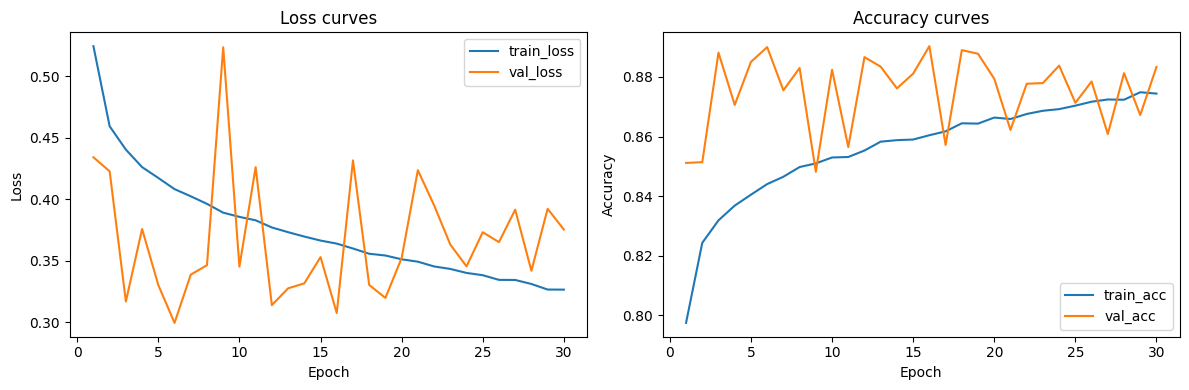

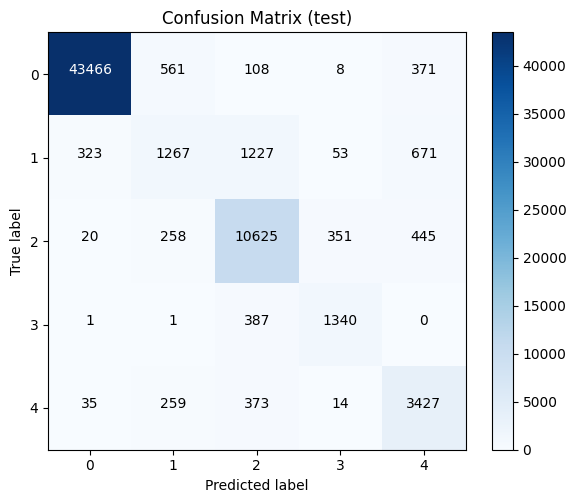

In [20]:
# ---------------------------
    # Plots: Loss/Accuracy curves & Confusion matrix
    # ---------------------------
epochs = np.arange(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves")

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy curves")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"))
plt.show()

    # Confusion matrix plot
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (test)")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, [str(i) for i in range(NUM_CLASSES)])
plt.yticks(tick_marks, [str(i) for i in range(NUM_CLASSES)])
plt.ylabel("True label")
plt.xlabel("Predicted label")
# write numbers
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"))
plt.show()